# Session 2 — Market Risk Basics: Returns, Volatility & Correlation
**Financial Risk Management and Engineering with Python**
Aarhus BSS Summer University 2026

---
We build intuition for the *statistical properties of financial returns* and implement
**volatility models** that are central to quantitative risk management.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from arch import arch_model
import yfinance as yf

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})
BLUE, RED, GREEN = '#2C7BB6', '#D7191C', '#1A9641'

# Download data
tickers = ['SPY', 'AAPL', 'GS', '^VIX']
raw  = yf.download(['SPY','AAPL','GS'], start='2010-01-01', end='2024-12-31',
                   auto_adjust=True, progress=False)['Close']
vix  = yf.download('^VIX', start='2010-01-01', end='2024-12-31',
                   auto_adjust=True, progress=False)['Close']
# Market index for the beta regressions (S&P 500)
idx_raw = yf.download('^GSPC', start='2010-01-01', end='2024-12-31',
                      auto_adjust=True, progress=False)['Close']
mkt_ret = np.log(idx_raw / idx_raw.shift(1)).dropna()
rets = np.log(raw / raw.shift(1)).dropna()
print(f"Returns: {rets.shape[0]} observations  {rets.index[0].date()} → {rets.index[-1].date()}")


Returns: 3772 observations  2010-01-05 → 2024-12-30


## 1. Stylised Facts of Financial Returns

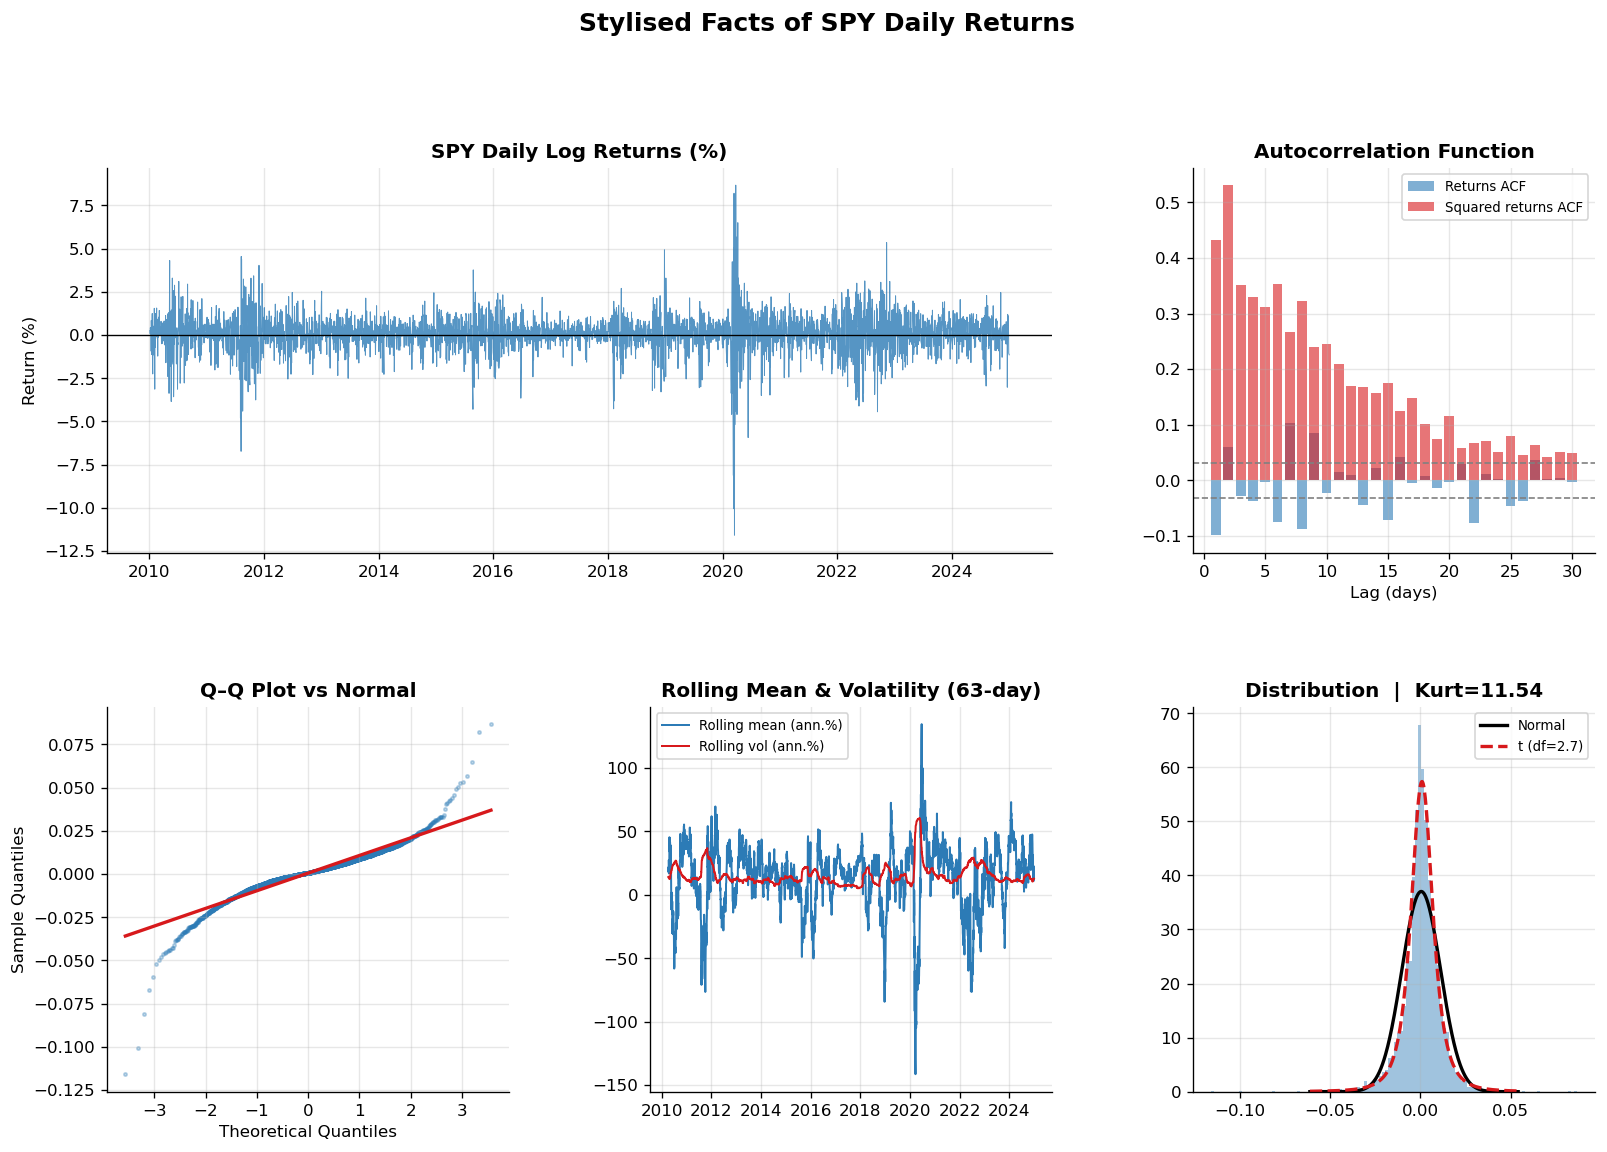

Jarque-Bera test: stat=21203.7, p-value=0.00e+00  → Reject normality ✗


In [2]:
r = rets['SPY'].dropna()

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Return time series
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(r.index, r*100, color=BLUE, lw=0.6, alpha=0.8)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_title('SPY Daily Log Returns (%)', fontweight='bold')
ax1.set_ylabel('Return (%)')

# ── Plot 2: ACF of returns
from pandas.plotting import autocorrelation_plot
ax2 = fig.add_subplot(gs[0, 2])
lags = range(1, 31)
acf_r  = [r.autocorr(lag=l) for l in lags]
acf_r2 = [(r**2).autocorr(lag=l) for l in lags]
ax2.bar(lags, acf_r,  alpha=0.6, color=BLUE,  label='Returns ACF')
ax2.bar(lags, acf_r2, alpha=0.6, color=RED,   label='Squared returns ACF')
ax2.axhline(1.96/np.sqrt(len(r)), color='gray', ls='--', lw=1)
ax2.axhline(-1.96/np.sqrt(len(r)), color='gray', ls='--', lw=1)
ax2.set_title('Autocorrelation Function', fontweight='bold')
ax2.set_xlabel('Lag (days)')
ax2.legend(fontsize=8)

# ── Plot 3: QQ-plot
ax3 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
ax3.scatter(osm, osr, s=4, alpha=0.3, color=BLUE)
ax3.plot(osm, slope*np.array(osm)+intercept, color=RED, lw=2)
ax3.set_title('Q–Q Plot vs Normal', fontweight='bold')
ax3.set_xlabel('Theoretical Quantiles'); ax3.set_ylabel('Sample Quantiles')

# ── Plot 4: Rolling mean and vol
ax4 = fig.add_subplot(gs[1, 1])
roll_mu  = r.rolling(63).mean() * 252 * 100
roll_sig = r.rolling(63).std()  * np.sqrt(252) * 100
ax4.plot(roll_mu.index,  roll_mu,  color=BLUE,  lw=1.2, label='Rolling mean (ann.%)')
ax4.plot(roll_sig.index, roll_sig, color=RED,   lw=1.2, label='Rolling vol (ann.%)')
ax4.set_title('Rolling Mean & Volatility (63-day)', fontweight='bold')
ax4.legend(fontsize=8)

# ── Plot 5: Histogram + normal + t
ax5 = fig.add_subplot(gs[1, 2])
x = np.linspace(r.quantile(0.001), r.quantile(0.999), 400)
ax5.hist(r, bins=120, density=True, alpha=0.45, color=BLUE)
ax5.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'k-', lw=2, label='Normal')
df_t, loc_t, sc_t = stats.t.fit(r)
ax5.plot(x, stats.t.pdf(x, df_t, loc_t, sc_t), '--', color=RED, lw=2,
         label=f't (df={df_t:.1f})')
ax5.set_title(f'Distribution  |  Kurt={r.kurt():.2f}', fontweight='bold')
ax5.legend(fontsize=8)

fig.suptitle('Stylised Facts of SPY Daily Returns', fontsize=15, fontweight='bold', y=1.01)
plt.show()

jb_stat, jb_p = stats.jarque_bera(r)
print(f"Jarque-Bera test: stat={jb_stat:.1f}, p-value={jb_p:.2e}  → {'Reject normality ✗' if jb_p < 0.05 else 'Cannot reject normality ✓'}")


## 2. Annualised Volatility and Beta (per Stock)

Per-stock risk summary (beta vs S&P 500):
       Ann. mean %  Ann. vol %  \
Stock                            
SPY         12.843      17.103   
AAPL        24.495      27.876   
GS           9.749      28.641   

                                                    Beta  \
Stock                                                      
SPY    [2.69172994636795e-35, 0.0, 1.07669197854718e-...   
AAPL   [-2.69172994636795e-35, -2.15338395709436e-34,...   
GS     [2.15338395709436e-34, 0.0, 2.15338395709436e-...   

                                                      R2  \
Stock                                                      
SPY    [4.5670921677505e-37, nan, 4.5670921677505e-37...   
AAPL   [4.5670921677505e-37, 4.5670921677505e-37, 4.5...   
GS     [4.5670921677505e-37, nan, 4.5670921677505e-37...   

                                                 Beta SE  \
Stock                                                      
SPY    [6.486955564600271e-19, nan, 2.594782225840108...   
AAPL 

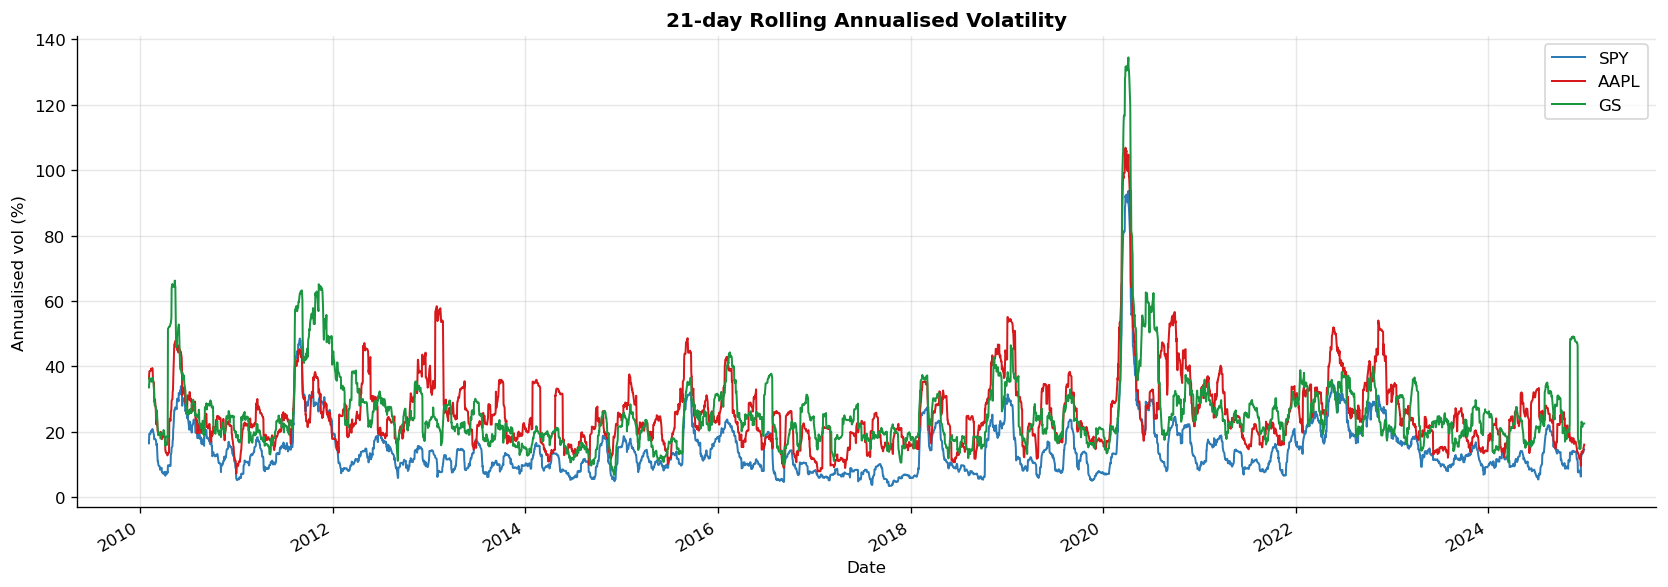

In [3]:
# Annualised mean/vol for each stock + market beta from an OLS regression on the index
stocks = ['SPY', 'AAPL', 'GS']
mkt = mkt_ret.reindex(rets.index).dropna()

rows = []
for s in stocks:
    y = rets[s].reindex(mkt.index).dropna()
    x = mkt.reindex(y.index)
    slope, intercept, rval, pval, se = stats.linregress(x, y)   # OLS: stock ~ market
    rows.append({'Stock': s,
                 'Ann. mean %': y.mean() * 252 * 100,
                 'Ann. vol %':  y.std() * np.sqrt(252) * 100,
                 'Beta': slope,
                 'R2': rval**2,
                 'Beta SE': se,
                 'Alpha ann %': intercept * 252 * 100})
summary_df = pd.DataFrame(rows).set_index('Stock').round(3)
print('Per-stock risk summary (beta vs S&P 500):')
print(summary_df)
print('\nSPY beta should be ~1.0 (it tracks the index) - a sanity check on the regression.')

# 21-day rolling annualised volatility for all three stocks
fig, ax = plt.subplots(figsize=(14, 5))
for s, col in zip(stocks, [BLUE, RED, GREEN]):
    (rets[s].rolling(21).std() * np.sqrt(252) * 100).plot(ax=ax, lw=1.2, color=col, label=s)
ax.set_title('21-day Rolling Annualised Volatility', fontweight='bold')
ax.set_ylabel('Annualised vol (%)')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Historical vs EWMA Volatility

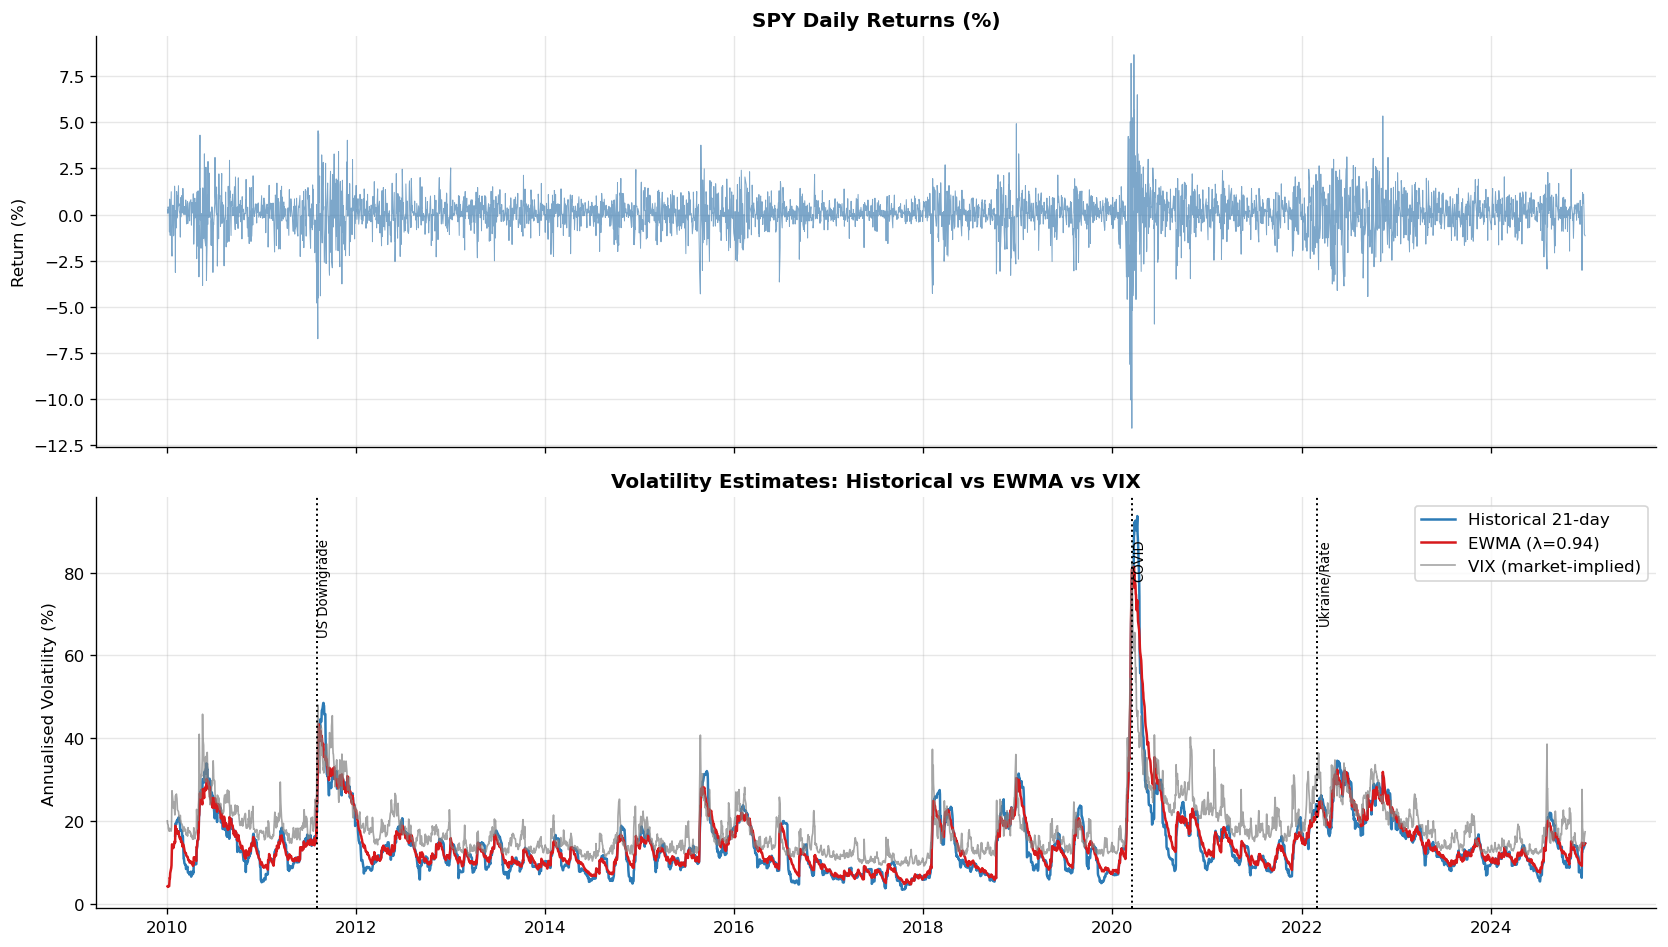

Correlation EWMA vs VIX: 0.869


In [4]:
lam = 0.94  # RiskMetrics decay factor

r_spy = rets['SPY'].dropna()

# Historical rolling 21-day
hist_vol = r_spy.rolling(21).std() * np.sqrt(252) * 100

# EWMA
ewma_var = r_spy.copy(); ewma_var.iloc[0] = r_spy.iloc[0]**2
for t in range(1, len(r_spy)):
    ewma_var.iloc[t] = lam * ewma_var.iloc[t-1] + (1-lam) * r_spy.iloc[t]**2
ewma_vol = np.sqrt(ewma_var) * np.sqrt(252) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(r_spy.index, r_spy*100, color='steelblue', lw=0.6, alpha=0.7)
axes[0].set_title('SPY Daily Returns (%)', fontweight='bold')
axes[0].set_ylabel('Return (%)')

axes[1].plot(hist_vol.index, hist_vol, color=BLUE, lw=1.5, label='Historical 21-day')
axes[1].plot(ewma_vol.index, ewma_vol, color=RED,  lw=1.5, label=f'EWMA (λ={lam})')
axes[1].plot(vix.index, vix, color='grey', lw=1, alpha=0.7, label='VIX (market-implied)')

for date, label in [('2011-08-05','US Downgrade'), ('2020-03-16','COVID'),
                    ('2022-03-01','Ukraine/Rate')]:
    axes[1].axvline(pd.Timestamp(date), color='black', ls=':', lw=1.2)
    axes[1].text(pd.Timestamp(date), axes[1].get_ylim()[1]*0.9,
                 label, rotation=90, fontsize=8, va='top')

axes[1].set_title('Volatility Estimates: Historical vs EWMA vs VIX', fontweight='bold')
axes[1].set_ylabel('Annualised Volatility (%)')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Correlation EWMA vs VIX: {pd.concat([ewma_vol, vix], axis=1).dropna().corr().iloc[0,1]:.3f}")


## 4. GARCH(1,1) - Fitting and Diagnostics

In [5]:
# Fit GARCH(1,1) to SPY returns (scaled to %)
r_pct = r_spy * 100
garch_model = arch_model(r_pct, vol='Garch', p=1, q=1, dist='t', mean='Zero')
res = garch_model.fit(disp='off')
print(res.summary())


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                          SPY   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4755.03
Distribution:      Standardized Student's t   AIC:                           9518.05
Method:                  Maximum Likelihood   BIC:                           9542.99
                                              No. Observations:                 3772
Date:                      Tue, Jul 07 2026   Df Residuals:                     3772
Time:                              10:04:36   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

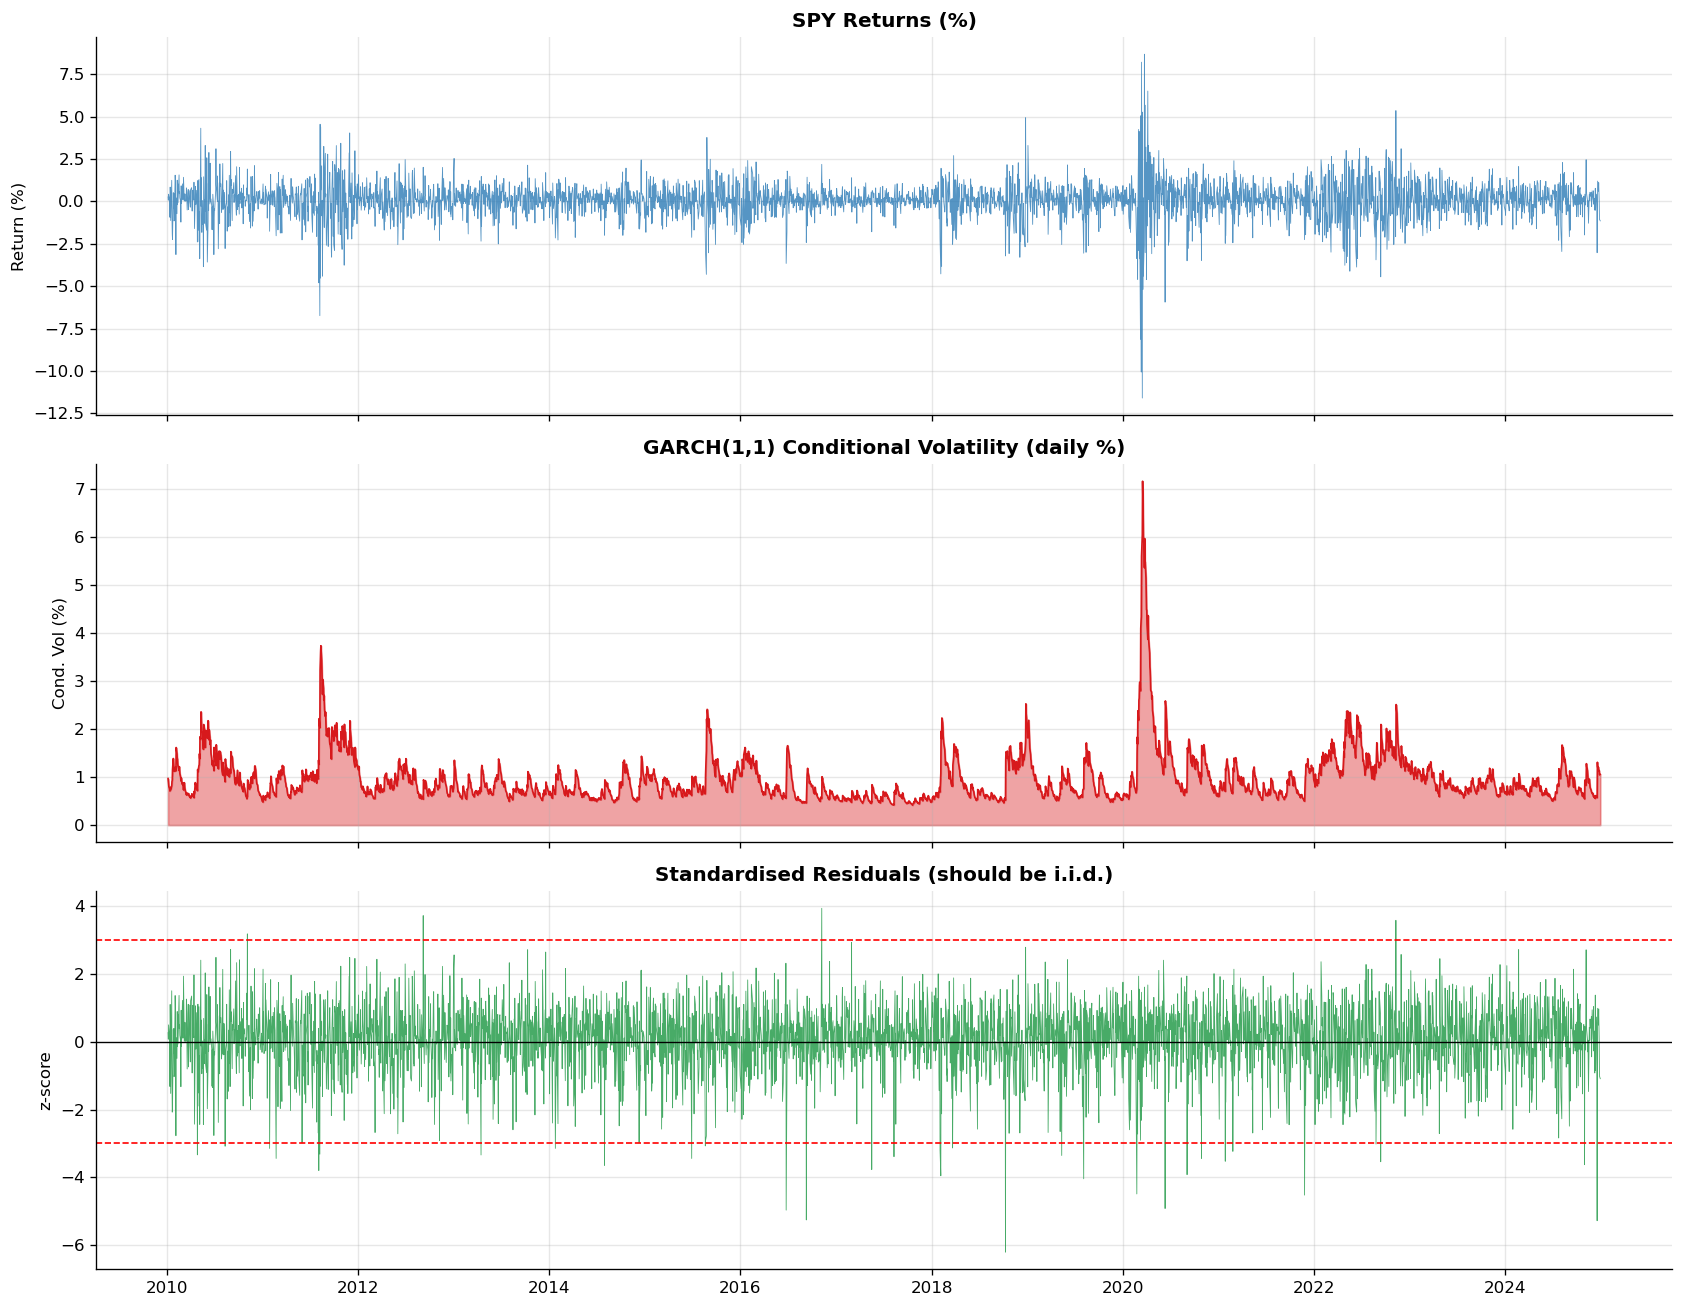


GARCH params: ω=0.023594, α=0.1547, β=0.8335
Persistence (α+β): 0.9881
Long-run annualised vol: 22.40%
Half-life of vol shock:  58.1 days

Ljung-Box on std. residuals   (lag 10): stat=10.81, p=0.372
Ljung-Box on std. residuals^2 (lag 10): stat=8.60, p=0.571
  High p-values => no autocorrelation left => GARCH(1,1) captured the volatility clustering.


In [6]:
# Extract fitted conditional volatility
cond_vol = res.conditional_volatility  # already in % units

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Returns
axes[0].plot(r_pct.index, r_pct, color=BLUE, lw=0.5, alpha=0.8)
axes[0].set_title('SPY Returns (%)', fontweight='bold')
axes[0].set_ylabel('Return (%)')

# GARCH conditional vol
axes[1].fill_between(cond_vol.index, cond_vol, alpha=0.4, color=RED)
axes[1].plot(cond_vol.index, cond_vol, color=RED, lw=1)
axes[1].set_title('GARCH(1,1) Conditional Volatility (daily %)', fontweight='bold')
axes[1].set_ylabel('Cond. Vol (%)')

# Standardised residuals
std_resid = res.resid / res.conditional_volatility
axes[2].plot(std_resid.index, std_resid, color=GREEN, lw=0.5, alpha=0.8)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].axhline(3, color='red', ls='--', lw=1)
axes[2].axhline(-3, color='red', ls='--', lw=1)
axes[2].set_title('Standardised Residuals (should be i.i.d.)', fontweight='bold')
axes[2].set_ylabel('z-score')

plt.tight_layout()
plt.show()

params = res.params
alpha, beta, omega = params.get('alpha[1]', params.get('a[1]', 0)),                      params.get('beta[1]',  params.get('b[1]',  0)),                      params['omega']
print(f"\nGARCH params: ω={omega:.6f}, α={alpha:.4f}, β={beta:.4f}")
print(f"Persistence (α+β): {alpha+beta:.4f}")
if alpha+beta < 1:
    lr_var = omega / (1 - alpha - beta)
    print(f"Long-run annualised vol: {np.sqrt(lr_var*252):.2f}%")
    half_life = np.log(0.5) / np.log(alpha + beta)
    print(f"Half-life of vol shock:  {half_life:.1f} days")

# Ljung-Box test: is there autocorrelation left in the standardised residuals?
from statsmodels.stats.diagnostic import acorr_ljungbox
lb  = acorr_ljungbox(std_resid.dropna(),      lags=[10], return_df=True)
lb2 = acorr_ljungbox((std_resid**2).dropna(), lags=[10], return_df=True)
print(f"\nLjung-Box on std. residuals   (lag 10): stat={lb['lb_stat'].iloc[0]:.2f}, p={lb['lb_pvalue'].iloc[0]:.3f}")
print(f"Ljung-Box on std. residuals^2 (lag 10): stat={lb2['lb_stat'].iloc[0]:.2f}, p={lb2['lb_pvalue'].iloc[0]:.3f}")
print("  High p-values => no autocorrelation left => GARCH(1,1) captured the volatility clustering.")


## 5. Correlation Matrix and Dynamic Correlations

Full-sample correlation matrix (2010-2024):
Ticker    SPY   AAPL     GS
Ticker                     
SPY     1.000  0.685  0.725
AAPL    0.685  1.000  0.417
GS      0.725  0.417  1.000


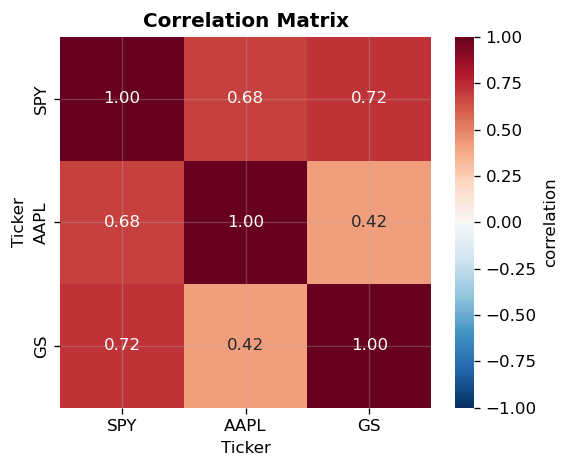

In [7]:
# Full-sample correlation matrix of daily log returns
corr_matrix = rets[['SPY', 'AAPL', 'GS']].corr()
print('Full-sample correlation matrix (2010-2024):')
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'correlation'}, ax=ax)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


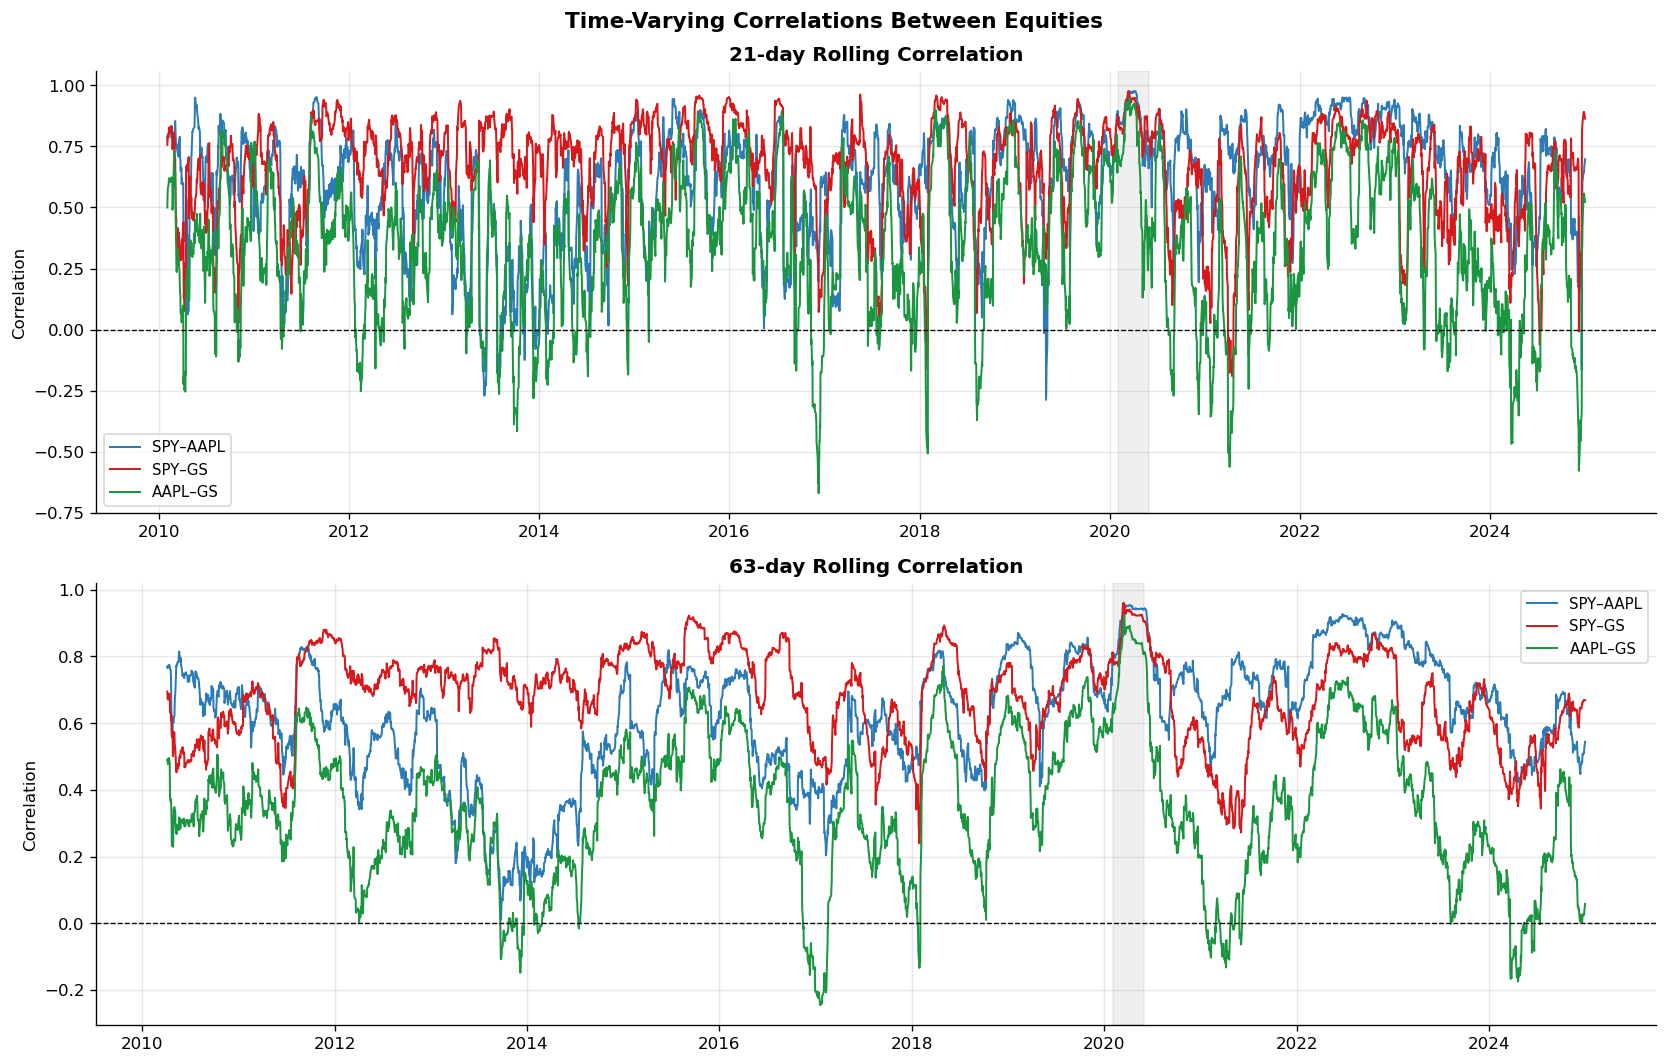

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Rolling 63-day correlations between asset pairs
pairs = [('SPY','AAPL'), ('SPY','GS'), ('AAPL','GS')]
colors_p = [BLUE, RED, GREEN]

for ax, window, title in zip(axes, [21, 63], ['21-day Rolling', '63-day Rolling']):
    for (a, b), col in zip(pairs, colors_p):
        roll_corr = rets[a].rolling(window).corr(rets[b])
        ax.plot(roll_corr.index, roll_corr, color=col, lw=1.2,
                label=f'{a}–{b}')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'{title} Correlation', fontweight='bold')
    ax.set_ylabel('Correlation')
    ax.legend(fontsize=9)
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
               alpha=0.12, color='grey')

plt.suptitle('Time-Varying Correlations Between Equities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Volatility Forecasting Comparison

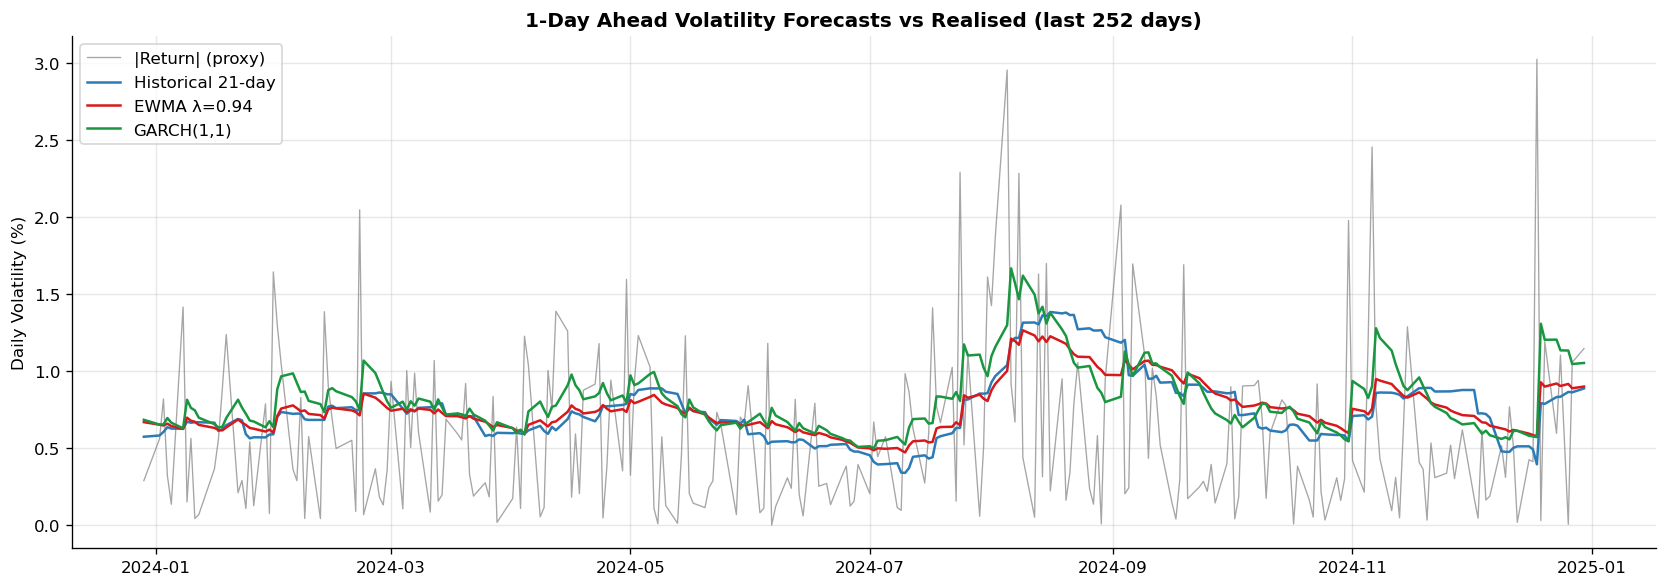

QLIKE Loss (lower is better):
  Historical: 0.7378
  EWMA:       0.5758
  GARCH:      0.5592


In [9]:
# Compare 1-day-ahead forecasts: historical vs EWMA vs GARCH
forecast_window = 252  # use last year as evaluation
test_rets = r_pct.iloc[-forecast_window:]

# Realised vol proxy: |r_t|
realised = test_rets.abs()

# Historical 21-day (fitted on preceding window)
hist_fc = r_pct.shift(1).rolling(21).std().iloc[-forecast_window:]

# EWMA recursive
ewma_fc_series = pd.Series(index=r_pct.index, dtype=float)
v = r_pct.iloc[0]**2
for t in range(1, len(r_pct)):
    v = lam*v + (1-lam)*r_pct.iloc[t-1]**2
    ewma_fc_series.iloc[t] = np.sqrt(v)
ewma_fc = ewma_fc_series.iloc[-forecast_window:]

# GARCH 1-step ahead
garch_fc = cond_vol.iloc[-forecast_window:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(realised.index, realised, color='grey', lw=0.8, alpha=0.7, label='|Return| (proxy)')
ax.plot(hist_fc.index,  hist_fc,  color=BLUE,  lw=1.5, label='Historical 21-day')
ax.plot(ewma_fc.index,  ewma_fc,  color=RED,   lw=1.5, label=f'EWMA λ={lam}')
ax.plot(garch_fc.index, garch_fc, color=GREEN, lw=1.5, label='GARCH(1,1)')
ax.set_title('1-Day Ahead Volatility Forecasts vs Realised (last 252 days)', fontweight='bold')
ax.set_ylabel('Daily Volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()

# QLIKE loss
def qlike(realised_sq, forecast):
    f = forecast.dropna()**2
    r = realised_sq.reindex(f.index)**2
    return (np.log(f) + r/f).mean()

print("QLIKE Loss (lower is better):")
print(f"  Historical: {qlike(test_rets, hist_fc):.4f}")
print(f"  EWMA:       {qlike(test_rets, ewma_fc):.4f}")
print(f"  GARCH:      {qlike(test_rets, garch_fc):.4f}")


## 7. Save All Outputs to CSV
These files are the Session 2 inputs to Assignment 1 and the Session 3 VaR lab.

In [10]:
# Persist every Session 2 output with a pinned date range (reproducibility)
import os
outdir = 'session2_outputs'
os.makedirs(outdir, exist_ok=True)

rets.to_csv(f'{outdir}/daily_log_returns.csv')
summary_df.to_csv(f'{outdir}/vol_beta_summary.csv')
corr_matrix.to_csv(f'{outdir}/correlation_matrix.csv')
ewma_vol.rename('EWMA_vol_ann_pct').to_csv(f'{outdir}/ewma_volatility_SPY.csv')
cond_vol.rename('GARCH_cond_vol_daily_pct').to_csv(f'{outdir}/garch_conditional_vol_SPY.csv')

print('Saved to', outdir + '/:')
for f in sorted(os.listdir(outdir)):
    print('  -', f)


Saved to session2_outputs/:
  - correlation_matrix.csv
  - daily_log_returns.csv
  - ewma_volatility_SPY.csv
  - garch_conditional_vol_SPY.csv
  - vol_beta_summary.csv


## Summary

| Model | Captures vol clustering | Fat tails | Computational cost |
|-------|------------------------|-----------|-------------------|
| Historical rolling sigma | Partially | No | Very low |
| EWMA (lambda=0.94) | Yes | No | Low |
| GARCH(1,1)-t | Yes | Via t-errors | Medium |

**Deliverables produced for Assignment 1:** annualised mean/vol per stock, beta vs the index (OLS),
full-sample and rolling correlation matrices, the EWMA series, the fitted GARCH(1,1) model
(persistence, long-run vol, half-life), the QLIKE model comparison, and CSV snapshots of every output.

**Next session:** we use these volatility estimates to compute **Value-at-Risk**.